# Data Profiling y Calidad de Datos - RENAMU 2022

## Objetivo
Este notebook documenta el profiling del archivo RENAMU disponible en Bronze. El objetivo es entender su estructura territorial y municipal, y evaluar su calidad con ocho dimensiones explicadas de forma clara para la defensa del parcial.

## Herramientas
- Python con `pandas`, `numpy` y `matplotlib`
- Partición Parquet `year=2022` en `data/bronze/renamu`

## Alcance
Se carga el archivo completo para preservar contexto, pero el profiling y la calidad se concentran en un subconjunto de variables clave: ano, identificadores territoriales, ubigeo, nombres geograficos y tipo de municipalidad.


In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display, Markdown
except ImportError:
    def display(obj):
        print(obj)

    def Markdown(text):
        return text

plt.style.use('default')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
RENAMU_PATH = PROJECT_ROOT / 'data' / 'bronze' / 'renamu'
RENAMU_TABLE_PATH = RENAMU_PATH / 'year=2022'


## 1. Carga del dataset

RENAMU se analiza desde la partición Parquet Bronze `year=2022`. El CSV y el ZIP originales permanecen en `data/raw`. Se conserva una columna auxiliar `source_file`, derivada de `_bronze_source_path`, junto con los metadatos técnicos `_bronze_*`.


In [2]:
renamu_df = pd.read_parquet(RENAMU_TABLE_PATH)
renamu_df['source_file'] = renamu_df['_bronze_source_path'].map(lambda value: Path(value).name)

key_columns = [
    'Año', 'idmunici', 'ccdd', 'ccpp', 'ccdi', 'Ubigeo', 'Departamento',
    'Provincia', 'Distrito', 'Tipomuni', 'source_file', '_bronze_source_url',
    '_bronze_source_checksum', '_bronze_execution_id', '_bronze_ingestion_date'
]
renamu_key_df = renamu_df[key_columns].copy()

for column in ['Año', 'Tipomuni']:
    renamu_key_df[column] = pd.to_numeric(renamu_key_df[column], errors='coerce')

for column in ['idmunici', 'ccdd', 'ccpp', 'ccdi', 'Ubigeo']:
    renamu_key_df[column] = renamu_key_df[column].astype('string').str.replace('.0', '', regex=False).str.strip()

print(f'Particion principal: {RENAMU_TABLE_PATH.name}')
print(f'Dimension de la tabla completa: {renamu_df.shape[0]:,} filas x {renamu_df.shape[1]:,} columnas'.replace(',', '.'))
print(f'Dimension del subconjunto clave: {renamu_key_df.shape[0]:,} filas x {renamu_key_df.shape[1]:,} columnas'.replace(',', '.'))


Particion principal: year=2022
Dimension de la tabla completa: 1.150 filas x 1.380 columnas
Dimension del subconjunto clave: 1.150 filas x 15 columnas


## 2. Entendimiento inicial de la estructura

Antes del profiling conviene revisar que representa cada fila, que columnas clave se usaran y como se comportan los tipos de datos en el subconjunto territorial.


In [3]:
column_summary = pd.DataFrame({
    'column': renamu_key_df.columns,
    'dtype': renamu_key_df.dtypes.astype(str).values,
    'non_null_count': renamu_key_df.notna().sum().values,
    'missing_ratio': renamu_key_df.isna().mean().round(4).values,
    'unique_values': [renamu_key_df[column].nunique(dropna=True) for column in renamu_key_df.columns],
}).sort_values(['missing_ratio', 'unique_values'], ascending=[False, False])

display(renamu_key_df.head())
display(column_summary)
display(renamu_key_df.describe(include='all').T)


,Año,idmunici,ccdd,ccpp,ccdi,Ubigeo,Departamento,Provincia,Distrito,Tipomuni,source_file,_bronze_source_url,_bronze_source_checksum,_bronze_execution_id,_bronze_ingestion_date
0,2022,010101,01,01,01,010101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,1,Base_RENAMU_2022_f.csv,https://www.inei.gob.pe/media/DATOS_ABIERTOS/R...,6a310d1c471aab86f5ed0190b43abe8b6ea8dda5083c92...,20260531_035501,2026-05-31
1,2022,010102,01,01,02,010102,AMAZONAS,CHACHAPOYAS,ASUNCION,2,Base_RENAMU_2022_f.csv,https://www.inei.gob.pe/media/DATOS_ABIERTOS/R...,6a310d1c471aab86f5ed0190b43abe8b6ea8dda5083c92...,20260531_035501,2026-05-31
2,2022,010103,01,01,03,010103,AMAZONAS,CHACHAPOYAS,BALSAS,2,Base_RENAMU_2022_f.csv,https://www.inei.gob.pe/media/DATOS_ABIERTOS/R...,6a310d1c471aab86f5ed0190b43abe8b6ea8dda5083c92...,20260531_035501,2026-05-31
3,2022,010104,01,01,04,010104,AMAZONAS,CHACHAPOYAS,CHETO,2,Base_RENAMU_2022_f.csv,https://www.inei.gob.pe/media/DATOS_ABIERTOS/R...,6a310d1c471aab86f5ed0190b43abe8b6ea8dda5083c92...,20260531_035501,2026-05-31
4,2022,010105,01,01,05,010105,AMAZONAS,CHACHAPOYAS,CHILIQUIN,2,Base_RENAMU_2022_f.csv,https://www.inei.gob.pe/media/DATOS_ABIERTOS/R...,6a310d1c471aab86f5ed0190b43abe8b6ea8dda5083c92...,20260531_035501,2026-05-31


,column,dtype,non_null_count,missing_ratio,unique_values
1,idmunici,string,1150,0.0,1150
5,Ubigeo,string,1150,0.0,1150
8,Distrito,object,1150,0.0,1068
7,Provincia,object,1150,0.0,111
4,ccdi,string,1150,0.0,36
3,ccpp,string,1150,0.0,20
2,ccdd,string,1150,0.0,12
6,Departamento,object,1150,0.0,12
9,Tipomuni,int64,1150,0.0,2
0,Año,int64,1150,0.0,1


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Año,1150.0,NaN,NaN,NaN,2022.0,0.0,2022.0,2022.0,2022.0,2022.0,2022.0
idmunici,1150,1150,010101,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ccdd,1150,12,02,166,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ccpp,1150,20,01,188,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ccdi,1150,36,01,111,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ubigeo,1150,1150,010101,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Departamento,1150,12,ANCASH,166,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Provincia,1150,111,JAUJA,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Distrito,1150,1068,SANTA ROSA,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tipomuni,1150.0,NaN,NaN,NaN,1.903478,0.295434,1.0,2.0,2.0,2.0,2.0


## 3. Data Profiling

A partir de aqui comienza formalmente el data profiling. En RENAMU interesa sobre todo la parte territorial, porque es la que permite usar la fuente como dimension municipal para enriquecer otros analisis.


### 3.1 Completitud: valores nulos

Esta subseccion muestra si las variables territoriales clave vienen completas o si existen vacios que podrian dificultar cruces por ubigeo o municipalidad.


,column,missing_ratio
0,Año,0.0
1,idmunici,0.0
2,ccdd,0.0
3,ccpp,0.0
4,ccdi,0.0
5,Ubigeo,0.0
6,Departamento,0.0
7,Provincia,0.0
8,Distrito,0.0
9,Tipomuni,0.0


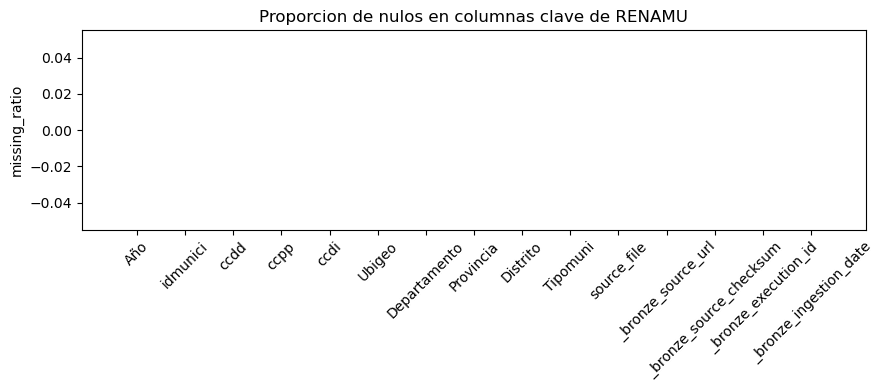

In [4]:
missing_by_column = renamu_key_df.isna().mean().sort_values(ascending=False).reset_index()
missing_by_column.columns = ['column', 'missing_ratio']
display(missing_by_column)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(missing_by_column['column'], missing_by_column['missing_ratio'], color='tab:blue')
ax.set_title('Proporcion de nulos en columnas clave de RENAMU')
ax.set_ylabel('missing_ratio')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


### 3.2 Duplicados

Como RENAMU puede usarse como dimension municipal, es importante revisar si `idmunici` o `Ubigeo` aparecen repetidos.


In [5]:
duplicate_id_ratio = renamu_key_df.duplicated(subset=['idmunici']).mean()
duplicate_ubigeo_ratio = renamu_key_df.duplicated(subset=['Ubigeo']).mean()

duplicate_summary = pd.DataFrame([
    {'revision': 'Duplicados por idmunici', 'ratio': round(duplicate_id_ratio, 4), 'records': int(renamu_key_df.duplicated(subset=['idmunici']).sum())},
    {'revision': 'Duplicados por Ubigeo', 'ratio': round(duplicate_ubigeo_ratio, 4), 'records': int(renamu_key_df.duplicated(subset=['Ubigeo']).sum())},
])
display(duplicate_summary)


,revision,ratio,records
0,Duplicados por idmunici,0.0,0
1,Duplicados por Ubigeo,0.0,0


### 3.3 Cardinalidad y distribucion de categorias

Esta seccion resume la variedad de identificadores y la distribucion por tipo de municipalidad. Asi se entiende rapidamente la diversidad de la fuente.


In [6]:
cardinality_df = pd.DataFrame({
    'column': renamu_key_df.columns,
    'unique_values': [renamu_key_df[column].nunique(dropna=True) for column in renamu_key_df.columns]
}).sort_values('unique_values', ascending=False)

dept_counts = renamu_key_df['Departamento'].value_counts(dropna=False).reset_index()
dept_counts.columns = ['Departamento', 'records']

tipo_counts = renamu_key_df['Tipomuni'].value_counts(dropna=False).reset_index()
tipo_counts.columns = ['Tipomuni', 'records']

display(cardinality_df)
display(dept_counts)
display(tipo_counts)


,column,unique_values
1,idmunici,1150
5,Ubigeo,1150
8,Distrito,1068
7,Provincia,111
4,ccdi,36
3,ccpp,20
2,ccdd,12
6,Departamento,12
9,Tipomuni,2
0,Año,1


,Departamento,records
0,ANCASH,166
1,CAJAMARCA,127
2,AYACUCHO,119
3,JUNIN,115
4,CUSCO,112
5,AREQUIPA,109
6,HUANCAVELICA,100
7,AMAZONAS,84
8,APURIMAC,84
9,HUANUCO,84


,Tipomuni,records
0,2,1039
1,1,111


### 3.4 Perfil territorial

Aqui se observa el reparto de registros por departamento. Es una forma simple de explicar la cobertura geografica del archivo trabajado.


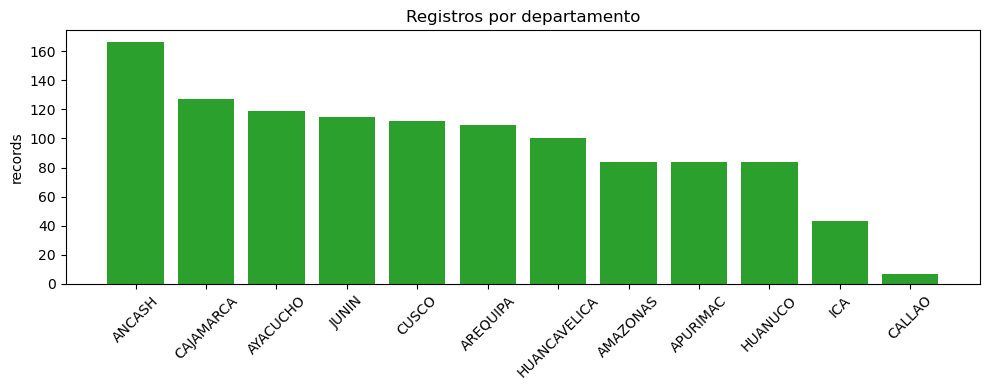

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(dept_counts['Departamento'].astype(str), dept_counts['records'], color='tab:green')
ax.set_title('Registros por departamento')
ax.set_ylabel('records')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


### 3.5 Perfil de identificadores

En RENAMU no basta con saber que hay filas; tambien interesa saber si los identificadores territoriales parecen utilizables para cruces con otras fuentes.


In [8]:
identifier_profile = pd.DataFrame([
    {'metric': 'Ubigeos unicos', 'value': int(renamu_key_df['Ubigeo'].nunique(dropna=True))},
    {'metric': 'idmunici unicos', 'value': int(renamu_key_df['idmunici'].nunique(dropna=True))},
    {'metric': 'Longitud valida de ubigeo (6)', 'value': round(renamu_key_df['Ubigeo'].fillna('').str.len().eq(6).mean(), 4)},
])
display(identifier_profile)


,metric,value
0,Ubigeos unicos,1150.0
1,idmunici unicos,1150.0
2,Longitud valida de ubigeo (6),1.0


## 4. Evaluacion de las 8 dimensiones de calidad

**A partir de esta seccion comienza formalmente la evaluacion de calidad de datos para RENAMU.** La evaluacion se concentra en los identificadores y atributos territoriales que mas valor aportan para enriquecer otras fuentes.


In [9]:
def classify_score(score: float) -> str:
    if pd.isna(score):
        return 'No evaluado'
    if score >= 0.95:
        return 'Alto'
    if score >= 0.80:
        return 'Medio'
    return 'Bajo'

core_columns = ['Año', 'idmunici', 'ccdd', 'ccpp', 'ccdi', 'Ubigeo', 'Departamento', 'Provincia', 'Distrito']
missing_core_ratio = renamu_key_df[core_columns].isna().mean().mean()

duplicate_ratio = renamu_key_df.duplicated(subset=['idmunici']).mean()

valid_year_ratio = renamu_key_df['Año'].eq(2022).mean()
valid_ubigeo_ratio = renamu_key_df['Ubigeo'].fillna('').str.len().eq(6).mean()
valid_tipo_ratio = renamu_key_df['Tipomuni'].dropna().isin([1, 2]).mean() if renamu_key_df['Tipomuni'].notna().any() else np.nan
validez_ratio = np.nanmean([valid_year_ratio, valid_ubigeo_ratio, valid_tipo_ratio])

expected_ubigeo = renamu_key_df['ccdd'].fillna('').str.zfill(2) + renamu_key_df['ccpp'].fillna('').str.zfill(2) + renamu_key_df['ccdi'].fillna('').str.zfill(2)
consistency_ratio = expected_ubigeo.eq(renamu_key_df['Ubigeo'].fillna('')).mean()

exactitud_ratio = renamu_key_df[['Departamento', 'Provincia', 'Distrito']].notna().all(axis=1).mean()
integrity_ratio = renamu_key_df[['idmunici', 'Ubigeo', 'Departamento', 'Provincia', 'Distrito']].notna().all(axis=1).mean()
actualidad_ratio = renamu_key_df['Año'].eq(2022).mean()
availability_ratio = float(RENAMU_TABLE_PATH.exists() and not renamu_key_df.empty)

quality_summary = pd.DataFrame([
    {'dimension': 'Completitud', 'metric': '1 - promedio de nulos en columnas territoriales clave', 'score': round(1 - missing_core_ratio, 4)},
    {'dimension': 'Unicidad', 'metric': '1 - proporcion de duplicados por idmunici', 'score': round(1 - duplicate_ratio, 4)},
    {'dimension': 'Validez', 'metric': 'reglas de ano, ubigeo y tipo municipal', 'score': round(validez_ratio, 4)},
    {'dimension': 'Consistencia', 'metric': 'Ubigeo coincide con ccdd+ccpp+ccdi', 'score': round(consistency_ratio, 4)},
    {'dimension': 'Exactitud', 'metric': 'presencia de nombres territoriales', 'score': round(exactitud_ratio, 4)},
    {'dimension': 'Integridad', 'metric': 'presencia conjunta de identificadores y geografia', 'score': round(integrity_ratio, 4)},
    {'dimension': 'Actualidad', 'metric': 'proporcion de registros del ano 2022', 'score': round(actualidad_ratio, 4)},
    {'dimension': 'Disponibilidad', 'metric': 'particion Parquet Bronze disponible y no vacia', 'score': round(availability_ratio, 4)},
])
quality_summary['nivel'] = quality_summary['score'].apply(classify_score)
quality_summary


,dimension,metric,score,nivel
0,Completitud,1 - promedio de nulos en columnas territoriale...,1.0,Alto
1,Unicidad,1 - proporcion de duplicados por idmunici,1.0,Alto
2,Validez,"reglas de ano, ubigeo y tipo municipal",1.0,Alto
3,Consistencia,Ubigeo coincide con ccdd+ccpp+ccdi,1.0,Alto
4,Exactitud,presencia de nombres territoriales,1.0,Alto
5,Integridad,presencia conjunta de identificadores y geografia,1.0,Alto
6,Actualidad,proporcion de registros del ano 2022,1.0,Alto
7,Disponibilidad,particion Parquet Bronze disponible y no vacia,1.0,Alto


### 4.1 Completitud

**Que significa:** revisar si las columnas territoriales minimas llegan completas.

**Como se midio:** se calculo el promedio de nulos en ano, identificadores, ubigeo y nombres geograficos.


In [10]:
completitud_detail = pd.DataFrame({
    'column': core_columns,
    'missing_ratio': renamu_key_df[core_columns].isna().mean().round(4).values,
    'completeness_score': (1 - renamu_key_df[core_columns].isna().mean()).round(4).values,
})
display(quality_summary[quality_summary['dimension'] == 'Completitud'])
display(completitud_detail)


,dimension,metric,score,nivel
0,Completitud,1 - promedio de nulos en columnas territoriale...,1.0,Alto


,column,missing_ratio,completeness_score
0,Año,0.0,1.0
1,idmunici,0.0,1.0
2,ccdd,0.0,1.0
3,ccpp,0.0,1.0
4,ccdi,0.0,1.0
5,Ubigeo,0.0,1.0
6,Departamento,0.0,1.0
7,Provincia,0.0,1.0
8,Distrito,0.0,1.0


### 4.2 Unicidad

**Que significa:** verificar si una municipalidad aparece repetida cuando se usa `idmunici` como identificador principal.

**Como se midio:** se calculo la proporcion de duplicados sobre `idmunici`.


In [11]:
unicidad_detail = pd.DataFrame([
    {'revision': 'Duplicados por idmunici', 'ratio': round(duplicate_ratio, 4), 'records': int(renamu_key_df.duplicated(subset=['idmunici']).sum())},
    {'revision': 'Duplicados por Ubigeo', 'ratio': round(duplicate_ubigeo_ratio, 4), 'records': int(renamu_key_df.duplicated(subset=['Ubigeo']).sum())},
])
display(quality_summary[quality_summary['dimension'] == 'Unicidad'])
display(unicidad_detail)


,dimension,metric,score,nivel
1,Unicidad,1 - proporcion de duplicados por idmunici,1.0,Alto


,revision,ratio,records
0,Duplicados por idmunici,0.0,0
1,Duplicados por Ubigeo,0.0,0


### 4.3 Validez

**Que significa:** comprobar si los valores cumplen reglas basicas esperadas para la fuente.

**Como se midio:** se valido que el ano sea 2022, que el ubigeo tenga longitud 6 y que el tipo de municipalidad pertenezca a categorias esperadas.


In [12]:
validez_detail = pd.DataFrame([
    {'regla': 'Año igual a 2022', 'score': round(valid_year_ratio, 4)},
    {'regla': 'Ubigeo con longitud 6', 'score': round(valid_ubigeo_ratio, 4)},
    {'regla': 'Tipomuni en {1, 2, 3}', 'score': round(valid_tipo_ratio, 4)},
])
display(quality_summary[quality_summary['dimension'] == 'Validez'])
display(validez_detail)


,dimension,metric,score,nivel
2,Validez,"reglas de ano, ubigeo y tipo municipal",1.0,Alto


,regla,score
0,Año igual a 2022,1.0
1,Ubigeo con longitud 6,1.0
2,"Tipomuni en {1, 2, 3}",1.0


### 4.4 Consistencia

**Que significa:** revisar si los identificadores territoriales coinciden entre si.

**Como se midio:** se comparo `Ubigeo` contra la concatenacion esperada de `ccdd`, `ccpp` y `ccdi`.


In [13]:
consistencia_detail = pd.DataFrame([
    {'regla': 'Ubigeo = ccdd + ccpp + ccdi', 'score': round(consistency_ratio, 4)},
])
display(quality_summary[quality_summary['dimension'] == 'Consistencia'])
display(consistencia_detail)


,dimension,metric,score,nivel
3,Consistencia,Ubigeo coincide con ccdd+ccpp+ccdi,1.0,Alto


,regla,score
0,Ubigeo = ccdd + ccpp + ccdi,1.0


### 4.5 Exactitud

**Que significa:** en esta fuente, una aproximacion razonable a exactitud es comprobar la presencia de nombres territoriales completos.

**Como se midio:** se reviso la presencia simultanea de departamento, provincia y distrito.


In [14]:
exactitud_detail = pd.DataFrame([
    {'regla': 'Nombres territoriales presentes', 'score': round(exactitud_ratio, 4)},
])
display(quality_summary[quality_summary['dimension'] == 'Exactitud'])
display(exactitud_detail)


,dimension,metric,score,nivel
4,Exactitud,presencia de nombres territoriales,1.0,Alto


,regla,score
0,Nombres territoriales presentes,1.0


### 4.6 Integridad

**Que significa:** evaluar si una fila contiene juntos los identificadores y atributos minimos para poder reutilizarla como dimension municipal.

**Como se midio:** se verifico la presencia conjunta de `idmunici`, `Ubigeo`, `Departamento`, `Provincia` y `Distrito`.


In [15]:
integridad_detail = pd.DataFrame([
    {'regla': 'Identificadores y geografia presentes', 'score': round(integrity_ratio, 4), 'complete_rows': int(renamu_key_df[['idmunici', 'Ubigeo', 'Departamento', 'Provincia', 'Distrito']].notna().all(axis=1).sum())},
])
display(quality_summary[quality_summary['dimension'] == 'Integridad'])
display(integridad_detail)


,dimension,metric,score,nivel
5,Integridad,presencia conjunta de identificadores y geografia,1.0,Alto


,regla,score,complete_rows
0,Identificadores y geografia presentes,1.0,1150


### 4.7 Actualidad

**Que significa:** comprobar si el archivo corresponde al ano que se esperaba analizar en el parcial.

**Como se midio:** se calculo la proporcion de registros cuyo ano es 2022.


In [16]:
actualidad_detail = pd.DataFrame([
    {'regla': 'Registros del año 2022', 'score': round(actualidad_ratio, 4), 'distinct_years': sorted(renamu_key_df['Año'].dropna().astype(int).unique().tolist())},
])
display(quality_summary[quality_summary['dimension'] == 'Actualidad'])
display(actualidad_detail)


,dimension,metric,score,nivel
6,Actualidad,proporcion de registros del ano 2022,1.0,Alto


,regla,score,distinct_years
0,Registros del año 2022,1.0,[2022]


### 4.8 Disponibilidad

**Que significa:** comprobar que la partición Parquet Bronze de RENAMU existe y contiene registros.

**Como se midio:** se verifico la disponibilidad de `year=2022` y que el dataframe no este vacio.

La trazabilidad se documenta adicionalmente con los metadatos técnicos `_bronze_*`.


In [17]:
trazabilidad_detail = renamu_key_df[
    ['source_file', '_bronze_source_url', '_bronze_source_checksum', '_bronze_execution_id', '_bronze_ingestion_date']
].drop_duplicates().sort_values('source_file')
display(quality_summary[quality_summary['dimension'] == 'Disponibilidad'])
display(trazabilidad_detail)


,dimension,metric,score,nivel
7,Disponibilidad,particion Parquet Bronze disponible y no vacia,1.0,Alto


,source_file,_bronze_source_url,_bronze_source_checksum,_bronze_execution_id,_bronze_ingestion_date
0,Base_RENAMU_2022_f.csv,https://www.inei.gob.pe/media/DATOS_ABIERTOS/R...,6a310d1c471aab86f5ed0190b43abe8b6ea8dda5083c92...,20260531_035501,2026-05-31


## 5. Resumen consolidado

Esta tabla reune las ocho dimensiones, la metrica utilizada y un nivel interpretativo simple. Es la mejor vista para una explicacion rapida del estado general de RENAMU.


In [18]:
display(quality_summary)


,dimension,metric,score,nivel
0,Completitud,1 - promedio de nulos en columnas territoriale...,1.0,Alto
1,Unicidad,1 - proporcion de duplicados por idmunici,1.0,Alto
2,Validez,"reglas de ano, ubigeo y tipo municipal",1.0,Alto
3,Consistencia,Ubigeo coincide con ccdd+ccpp+ccdi,1.0,Alto
4,Exactitud,presencia de nombres territoriales,1.0,Alto
5,Integridad,presencia conjunta de identificadores y geografia,1.0,Alto
6,Actualidad,proporcion de registros del ano 2022,1.0,Alto
7,Disponibilidad,particion Parquet Bronze disponible y no vacia,1.0,Alto


## 6. Conclusiones

En esta parte se sintetiza por que RENAMU es util y que limitaciones deben explicarse para no sobreprometer su uso.


In [19]:
worst_dimension = quality_summary.sort_values('score').iloc[0]
conclusion_lines = [
    f'- RENAMU contiene {len(renamu_key_df):,} registros municipales y {renamu_df.shape[1]} columnas en total.'.replace(',', '.'),
    f'- Los departamentos representados son {renamu_key_df["Departamento"].nunique(dropna=True)}.',
    f'- La dimension que requiere mas explicacion es {worst_dimension["dimension"]} con score {worst_dimension["score"]:.4f}.',
    '- RENAMU es util como dimension municipal y territorial, pero requiere cuidado cuando se usa `Ubigeo` para cruces automaticos.'
]
display(Markdown('\n'.join(conclusion_lines)))


- RENAMU contiene 1.150 registros municipales y 1380 columnas en total.
- Los departamentos representados son 12.
- La dimension que requiere mas explicacion es Completitud con score 1.0000.
- RENAMU es util como dimension municipal y territorial, pero requiere cuidado cuando se usa `Ubigeo` para cruces automaticos.

## 7. Recomendaciones

Estas recomendaciones muestran que el profiling tambien sirve para definir como deberia limpiarse o estandarizarse la fuente antes de usarla en capas posteriores.


In [20]:
recommendation_lines = [
    '- Normalizar `Ubigeo`, `ccdd`, `ccpp` y `ccdi` antes de usar la fuente en joins con otras tablas.',
    '- Mantener `idmunici` y los metadatos `_bronze_*` como apoyo para trazabilidad y validacion.',
    '- Revisar la coherencia territorial antes de construir una capa Silver o una dimension geoespacial.',
    '- Si se integran otras fuentes municipales, definir una regla unica de llave territorial para evitar cruces ambiguos.'
]
display(Markdown('\n'.join(recommendation_lines)))


- Normalizar `Ubigeo`, `ccdd`, `ccpp` y `ccdi` antes de usar la fuente en joins con otras tablas.
- Mantener `idmunici` y los metadatos `_bronze_*` como apoyo para trazabilidad y validacion.
- Revisar la coherencia territorial antes de construir una capa Silver o una dimension geoespacial.
- Si se integran otras fuentes municipales, definir una regla unica de llave territorial para evitar cruces ambiguos.